In [1]:
# analysis specific imports
import spacenet as sn
import muspan as ms

# general imports
import numpy as np
import pandas as pd 
import networkx as nx
import matplotlib.pyplot as plt 
import os 

# additional imports
os.chdir('../misc')
from cross_pair_correlation_function import cross_pair_correlation_function
from normalised_cross_correlation import normalised_cross_correlation

np.random.seed(15)  # For reproducibility

# for better res plots
plt.rcParams['figure.dpi'] = 200

max_dist = 500
kernel_n = 2
r_step=5

bandwidths = 45

netPCF_kwargs_1 = dict(spatial_kernel_bandwidth=bandwidths,
                        spatial_kernel_n=kernel_n,
                        r_min=0, 
                        r_max=max_dist,
                        r_step=r_step, 
                        return_confidence_interval=True,
                        verbose=True,
                        n_jobs=-1) 


pcf_kwargs_1 = dict(max_R=max_dist,
                annulus_step=r_step,
                annulus_width=bandwidths*2,
                return_confidence_interval=True)




region_size = (1000, 1000)
muspan_domain_boundary = np.array([[0, 0],
                                    [region_size[0], 0],
                                    [region_size[0], region_size[1]],
                                    [0, region_size[1]]])

# load in required data
spiral_df = pd.read_csv('../data/synthetic_data/spiral_domain.csv')
points_spiral = spiral_df[['x','y']].to_numpy() 
points_spiral= (points_spiral/2 + 500) +np.array([-25,50])

points_with_holes_removed = np.loadtxt('../data/synthetic_data/points_ppp_with_holes.csv',delimiter=',')


### holes

G_holes=sn.utils.spatial_network_from_points(points_with_holes_removed,network_type='delaunay',max_edge_distance=80)

# compute netPCF
r1,g1,CI1 = sn.point_patterns.cross_pair_correlation_function(G_holes,**netPCF_kwargs_1)

# compute PCF
holes_domain = ms.domain('ppp')
holes_domain.add_points(points_with_holes_removed,'points')
holes_domain.estimate_boundary('specify', specify_boundary_coords=muspan_domain_boundary)

r_pcf1,g_pcf1,CI_pcf1 = cross_pair_correlation_function(holes_domain,population_A=('collection','points'),population_B=('collection','points'),**pcf_kwargs_1)




### branching 
np.random.seed(15)  # For reproducibility

# Define the region size and Poisson point process parameters
region_size = (1000, 1000)
lambda_points = 0.002  # Density of points

# Generate points using a Poisson point process
num_points = int(region_size[0] * region_size[1] * lambda_points)
points = np.random.uniform(0, region_size[0], size=(num_points, 2))


rectangle = np.array([[-100,-300],[100,-300],[100,300],[-100,300]])
centre_points= np.array([[990/2,400],[660,700],[330,700]])

rotate_angle= np.array([0,-np.pi/4,np.pi/4])

# make shapes
shapes = []
for i,c in enumerate(centre_points):
    # Create a rotated rectangle
    rotation_matrix = np.array([[np.cos(rotate_angle[i]), -np.sin(rotate_angle[i])],
                                 [np.sin(rotate_angle[i]), np.cos(rotate_angle[i])]])
    rotated_rectangle = rectangle @ rotation_matrix.T + c

    # Add the rotated rectangle to the points
    shapes.append(rotated_rectangle)


pc=ms.domain('Test')

pc.add_points(points,'PPP')
Centre_id=pc.add_points(np.mean(centre_points,axis=0,keepdims=True),'centre',return_IDs=True)
pc.add_shapes(shapes,'shapes')


q_points_in_shape=ms.query.query(pc,('contains',(('object','point'),('collection','shapes'))),'is',True)   
q_points_in_shape_index = ms.query.interpret_query(q_points_in_shape)

G = ms.networks.generate_network(pc,network_name='DT',network_type='DT',max_edge_distance=80,objects_as_nodes=q_points_in_shape)



distance_from_center = nx.single_source_dijkstra_path_length(G,source=Centre_id[0],weight='Distance')
pc.add_labels('center_distance',list(distance_from_center.values()),add_labels_to=list(distance_from_center.keys()),label_type='continuous')
centroids,oids = ms.query.get_centroids(pc)

points_branching = centroids[np.isin(oids,q_points_in_shape_index)]

G_branch=sn.utils.spatial_network_from_points(points_branching,network_type='delaunay',max_edge_distance=80)



# compute netPCF
r2,g2,CI2 = sn.point_patterns.cross_pair_correlation_function(G_branch,**netPCF_kwargs_1)
# compute PCF
branch_domain=ms.domain('ppp')
branch_domain.add_points(points_branching,'points')
r_pcf2,g_pcf2,CI_pcf2 = cross_pair_correlation_function(branch_domain,population_A=('collection','points'),population_B=('collection','points'),**pcf_kwargs_1)


### spiral

G_spiral=sn.utils.spatial_network_from_points(points_spiral,network_type='delaunay',max_edge_distance=75)

# compute netPCF
r3,g3,CI3 = sn.point_patterns.cross_pair_correlation_function(G_spiral,**netPCF_kwargs_1)
# compute PCF
spiral_domain=ms.domain('ppp')
spiral_domain.add_points(points_spiral,'points')
#spiral_domain.estimate_boundary('alpha shape', alpha_shape_kwargs=dict(alpha=102))

r_pcf3,g_pcf3,CI_pcf3 = cross_pair_correlation_function(spiral_domain,population_A=('collection','points'),population_B=('collection','points'),**pcf_kwargs_1)


Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 1351/1351 [00:06<00:00, 213.71contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 564/564 [00:05<00:00, 110.44contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 1159/1159 [00:05<00:00, 227.89contributions/s]


Computing confidence intervals via spatial bootstrap...


In [2]:
# compare pcf curves

ncc_1,_ = normalised_cross_correlation(g1,g_pcf1)
ncc_2,_ = normalised_cross_correlation(g2,g_pcf2)
ncc_3,_ = normalised_cross_correlation(g3,g_pcf3)

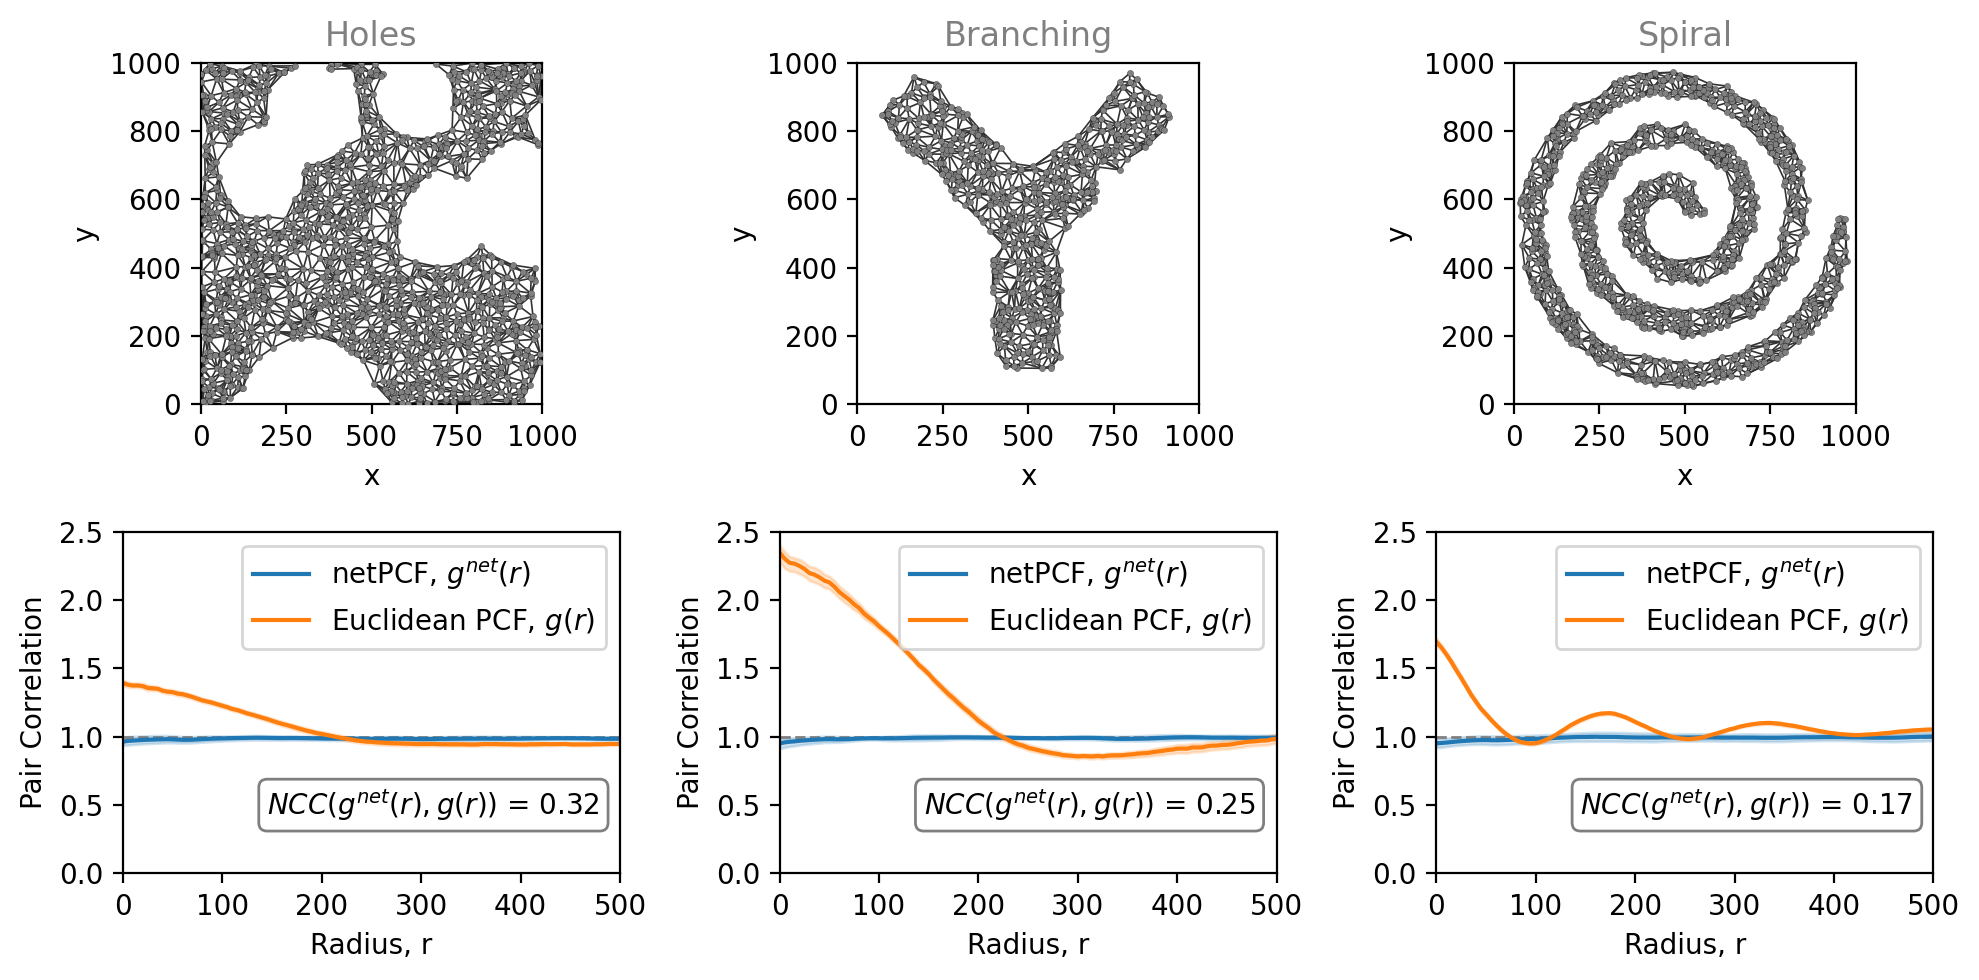

In [3]:

scatter_kwargs=dict(linewidths=0.1,edgecolors='black')
visualise_paras = dict(edge_width=0.6,marker_size=5,add_node_cbar=False,edge_weight_name=None,scatter_kwargs=scatter_kwargs) 
scalebar_kwargs = dict(size=100, label='',loc='lower right',pad = 1.5,frameon=False,size_vertical=10,zorder=1000)

fig,ax=plt.subplots(2,3,figsize=(10,5),layout='tight') 


### Plot holdes
sn.utils.plot_spatial_network(G_holes,ax=ax[0,0],**visualise_paras,edge_vmax=500,edge_vmin=0)
ax[0,0].set_title('Holes',color='grey')
ax[0,0].set_xlim(0, region_size[0])
ax[0,0].set_ylim(0, region_size[1])


# Turn on axis spines
ax[0,0].set_axis_on()
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('y')
ax[0,0].set_xlim(0, region_size[0]) 
ax[0,0].set_ylim(0, region_size[1]) 

ax[1,0].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[1,0].plot(r1,g1,color='tab:blue',label='netPCF, $g^{net}(r)$') 
ax[1,0].fill_between(r1, CI1[0], CI1[1], color='tab:blue', alpha=0.2)

ax[1,0].plot(r_pcf1,g_pcf1,color='tab:orange',label='Euclidean PCF, $g(r)$') 
ax[1,0].fill_between(r_pcf1, CI_pcf1[0], CI_pcf1[1], color='tab:orange', alpha=0.2)

ax[1,0].set_xlabel('Radius, r')
ax[1,0].set_ylabel('Pair Correlation')
ax[1,0].set_xlim(0, 500)  
ax[1,0].set_ylim(0, 2.5)
ax[1,0].legend()

error_1 = '$NCC(g^{net}(r),g(r))$ = ' f'{ncc_1:.2f}'
ax[1,0].text(145,0.5,error_1,va='center',ha='left',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

### plot holes and clusters
sn.utils.plot_spatial_network(G_branch,ax=ax[0,1],**visualise_paras,edge_vmax=500,edge_vmin=0)
ax[0,1].set_axis_on()
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
ax[0,1].set_xlim(0, region_size[0]) 
ax[0,1].set_ylim(0, region_size[1]) 
ax[0,1].set_title('Branching',color='grey')


# plot results
ax[1,1].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[1,1].plot(r2,g2,color='tab:blue',label='netPCF, $g^{net}(r)$') 
ax[1,1].fill_between(r2, CI2[0], CI2[1], color='tab:blue', alpha=0.2)

ax[1,1].plot(r_pcf2,g_pcf2,color='tab:orange',label='Euclidean PCF, $g(r)$') 
ax[1,1].fill_between(r_pcf2, CI_pcf2[0], CI_pcf2[1], color='tab:orange', alpha=0.2)

ax[1,1].set_xlabel('Radius, r')
ax[1,1].set_ylabel('Pair Correlation')
ax[1,1].set_xlim(0, max_dist)  
ax[1,1].set_ylim(0, 2.5)
ax[1,1].legend(loc='upper right')

error_2 = '$NCC(g^{net}(r),g(r))$ = ' f'{ncc_2:.2f}'
ax[1,1].text(145,0.5,error_2,va='center',ha='left',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

### plot sprial 

sn.utils.plot_spatial_network(G_spiral,ax=ax[0,2],**visualise_paras,edge_vmax=500,edge_vmin=0)
ax[0,2].set_axis_on()
ax[0,2].set_xlabel('x')
ax[0,2].set_ylabel('y')
ax[0,2].set_xlim(0, region_size[0]) 
ax[0,2].set_ylim(0, region_size[1]) 
ax[0,2].set_title('Spiral',color='grey')



# plot results
ax[1,2].axhline(1, color='gray', linestyle='--', linewidth=1)    
ax[1,2].plot(r3,g3,color='tab:blue',label='netPCF, $g^{net}(r)$') 
ax[1,2].fill_between(r3, CI3[0], CI3[1], color='tab:blue', alpha=0.2)
ax[1,2].plot(r_pcf3,g_pcf3,color='tab:orange',label='Euclidean PCF, $g(r)$') 
ax[1,2].fill_between(r_pcf3, CI_pcf3[0], CI_pcf3[1], color='tab:orange', alpha=0.2)

ax[1,2].set_xlabel('Radius, r')
ax[1,2].set_ylabel('Pair Correlation')
ax[1,2].set_xlim(0, max_dist)  
ax[1,2].set_ylim(0, 2.5)
ax[1,2].legend()

error_3 = '$NCC(g^{net}(r),g(r))$ = ' f'{ncc_3:.2f}'
ax[1,2].text(145,0.5,error_3,va='center',ha='left',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.show()
